In [1]:
# Cell 1: Setup and imports
import pandas as pd
import json
import random
from datetime import datetime, timedelta
import uuid

print("✅ Imports loaded")

✅ Imports loaded


In [3]:
# Cell 2: Create synthetic user support tickets
print("="*60)
print("🎫 CREATING SUPPORT TICKETS")
print("="*60)

# Define ticket categories relevant to ByteDance products
categories = {
    "TikTok": ["views", "shadowban", "algorithm", "upload", "sound", "follower"],
    "CapCut": ["export", "login", "template", "crash", "watermark"],
    "Lark": ["meeting", "calendar", "permission", "notification", "sync"]
}

languages = ["en", "id", "ms", "zh-CN", "th"]  # ByteDance key markets

# Create 50 synthetic tickets
tickets = []

for i in range(1, 51):
    product = random.choice(list(categories.keys()))
    issue_type = random.choice(categories[product])
    language = random.choice(languages)
    
    # Generate realistic queries
    queries = {
        ("TikTok", "views"): "My video views dropped from 10k to 100 overnight",
        ("TikTok", "shadowban"): "I think I'm shadowbanned, my content isn't showing on FYP",
        ("TikTok", "algorithm"): "How does the TikTok algorithm work now?",
        ("CapCut", "export"): "Export keeps failing at 50% on my CapCut project",
        ("CapCut", "login"): "Can't login to CapCut, says 'network error'",
        ("Lark", "meeting"): "Meeting recordings not showing in Lark calendar"
    }
    
    query_text = queries.get((product, issue_type), f"{issue_type} issue with {product}")
    
    ticket = {
        "ticket_id": f"TKT-{datetime.now().strftime('%Y%m')}-{i:04d}",
        "timestamp": (datetime.now() - timedelta(days=random.randint(0, 30))).isoformat(),
        "product": product,
        "issue_type": issue_type,
        "language": language,
        "user_query": query_text,
        "user_region": random.choice(["Indonesia", "Malaysia", "Singapore", "Thailand", "US"]),
        "priority": random.choice(["low", "medium", "high", "urgent"]),
        "status": random.choice(["open", "in_progress", "resolved"])
    }
    tickets.append(ticket)

tickets_df = pd.DataFrame(tickets)
print(f"✅ Created {len(tickets_df)} support tickets")
print(f"\n📊 Sample ticket:")
print(tickets_df.iloc[0].to_string())

🎫 CREATING SUPPORT TICKETS
✅ Created 50 support tickets

📊 Sample ticket:
ticket_id                  TKT-202605-0001
timestamp       2026-05-05T11:31:13.059535
product                             CapCut
issue_type                       watermark
language                                th
user_query     watermark issue with CapCut
user_region                       Thailand
priority                            urgent
status                            resolved


In [4]:
# Cell 3: Create knowledge base articles 
print("\n" + "="*60)
print("📚 CREATING KNOWLEDGE BASE")
print("="*60)

knowledge_base = [
    {
        "doc_id": "KB-001",
        "title": "TikTok Algorithm Guide 2025",
        "content": "The TikTok algorithm prioritizes watch time (60%), completion rate (25%), and engagement (15%). For best results, post when your audience is active (7-9 PM local time).",
        "tags": ["tiktok", "algorithm", "growth"],
        "language": "en",
        "last_updated": "2025-01-15"
    },
    {
        "doc_id": "KB-002",
        "title": "Shadowban Resolution Process",
        "content": "Shadowbans occur when content violates guidelines. To resolve: 1) Check account status in Settings > Report a Problem, 2) Remove violating content, 3) Wait 72 hours, 4) Contact support if persists.",
        "tags": ["tiktok", "shadowban", "account"],
        "language": "en",
        "last_updated": "2025-01-20"
    },
    {
        "doc_id": "KB-003",
        "title": "CapCut Login Troubleshooting",
        "content": "CapCut login issues: Clear cache (Settings > Apps > CapCut > Clear Cache), update to latest version, check internet connection, or use 'Forgot Password' feature.",
        "tags": ["capcut", "login", "troubleshooting"],
        "language": "en",
        "last_updated": "2025-02-01"
    },
    {
        "doc_id": "KB-004",
        "title": "Panduan Pengguna TikTok Indonesia",
        "content": "Untuk hasil terbaik di TikTok Indonesia, posting antara jam 7-9 malam WIB. Gunakan musik lokal dan caption dalam Bahasa Indonesia untuk engagement lebih tinggi.",
        "tags": ["tiktok", "indonesia", "tips"],
        "language": "id",
        "last_updated": "2025-01-10"
    },
    {
        "doc_id": "KB-005",
        "title": "Panduan CapCut Bahasa Melayu",
        "content": "Cara atasi masalah eksport CapCut: Pastikan ruang storan mencukupi, tutup aplikasi lain, dan gunakan format eksport H.264 untuk hasil terbaik.",
        "tags": ["capcut", "malaysia", "export"],
        "language": "ms",
        "last_updated": "2025-01-25"
    },
    {
        "doc_id": "KB-006",
        "title": "Lark Administration Guide",
        "content": "Lark supports SSO integration, audit logs, and role-based access control. Admins can configure security policies in Admin Console > Security Settings.",
        "tags": ["lark", "admin", "security"],
        "language": "en",
        "last_updated": "2025-02-05"
    },
    {
        "doc_id": "KB-007",
        "title": "Data Privacy at ByteDance",
        "content": "ByteDance complies with GDPR, CCPA, and PDPA. User data is encrypted at rest (AES-256) and in transit (TLS 1.3). Data retention is 30 days for inactive accounts.",
        "tags": ["privacy", "security", "compliance"],
        "language": "en",
        "last_updated": "2025-01-30"
    }
]

kb_df = pd.DataFrame(knowledge_base)
print(f"✅ Created {len(kb_df)} knowledge articles")
print(f"\n📚 Sample article:")
print(f"   {kb_df.iloc[0]['title']}")
print(f"   {kb_df.iloc[0]['content'][:100]}...")


📚 CREATING KNOWLEDGE BASE
✅ Created 7 knowledge articles

📚 Sample article:
   TikTok Algorithm Guide 2025
   The TikTok algorithm prioritizes watch time (60%), completion rate (25%), and engagement (15%). For ...


In [5]:
# Cell 4: Create ground truth labels for evaluation
print("\n" + "="*60)
print("🏷️  CREATING GROUND TRUTH LABELS")
print("="*60)

# Manually map tickets to relevant KB articles
ground_truth = []

# Rule-based mapping for evaluation
mapping_rules = [
    ("views", "algorithm", ["KB-001"]),
    ("shadowban", "shadowban", ["KB-002"]),
    ("login", "login", ["KB-003"]),
    ("export", "export", ["KB-005"]),
    ("algorithm", "algorithm", ["KB-001"]),
    ("privacy", "privacy", ["KB-007"]),
]

for _, ticket in tickets_df.iterrows():
    relevant_docs = []
    
    for keyword, _, docs in mapping_rules:
        if keyword in ticket['user_query'].lower() or keyword in ticket['issue_type'].lower():
            relevant_docs.extend(docs)
    
    # If no match, use default
    if not relevant_docs:
        relevant_docs = ["KB-006"]  # Lark guide as default
    
    ground_truth.append({
        "ticket_id": ticket['ticket_id'],
        "query": ticket['user_query'],
        "relevant_doc_ids": list(set(relevant_docs)),  # Remove duplicates
        "expected_confidence": 0.9 if len(relevant_docs) > 0 else 0.5
    })

gt_df = pd.DataFrame(ground_truth)
print(f"✅ Created {len(gt_df)} ground truth labels")
print(f"\n📊 Sample ground truth:")
print(gt_df.iloc[0].to_string())


🏷️  CREATING GROUND TRUTH LABELS
✅ Created 50 ground truth labels

📊 Sample ground truth:
ticket_id                          TKT-202605-0001
query                  watermark issue with CapCut
relevant_doc_ids                          [KB-006]
expected_confidence                            0.9


In [6]:
# Cell 5: Data validation and cleaning
print("\n" + "="*60)
print("🔍 DATA VALIDATION & CLEANING")
print("="*60)

# Check for missing values
print("\n📊 Missing values check:")
print(tickets_df.isnull().sum())

# Check for duplicate tickets
duplicate_queries = tickets_df['user_query'].duplicated().sum()
print(f"\n📊 Duplicate queries: {duplicate_queries}")

# Language distribution
print("\n🌐 Language distribution in tickets:")
lang_dist = tickets_df['language'].value_counts()
for lang, count in lang_dist.items():
    print(f"   {lang}: {count} tickets ({count/len(tickets_df)*100:.1f}%)")

# Product distribution
print("\n📱 Product distribution:")
prod_dist = tickets_df['product'].value_counts()
for prod, count in prod_dist.items():
    print(f"   {prod}: {count} tickets ({count/len(tickets_df)*100:.1f}%)")

# Priority distribution
print("\n⚠️ Priority distribution:")
priority_dist = tickets_df['priority'].value_counts()
for priority, count in priority_dist.items():
    print(f"   {priority}: {count} tickets")


🔍 DATA VALIDATION & CLEANING

📊 Missing values check:
ticket_id      0
timestamp      0
product        0
issue_type     0
language       0
user_query     0
user_region    0
priority       0
status         0
dtype: int64

📊 Duplicate queries: 35

🌐 Language distribution in tickets:
   ms: 15 tickets (30.0%)
   en: 11 tickets (22.0%)
   th: 10 tickets (20.0%)
   zh-CN: 10 tickets (20.0%)
   id: 4 tickets (8.0%)

📱 Product distribution:
   Lark: 19 tickets (38.0%)
   CapCut: 18 tickets (36.0%)
   TikTok: 13 tickets (26.0%)

⚠️ Priority distribution:
   low: 15 tickets
   urgent: 14 tickets
   medium: 14 tickets
   high: 7 tickets


In [7]:
# Cell 6: Export data for Notebooks 2-4
print("\n" + "="*60)
print("💾 EXPORTING DATA FOR NEXT NOTEBOOKS")
print("="*60)

# Save tickets
tickets_df.to_json('byte_dance_tickets.json', orient='records', indent=2)
print("✅ Saved: byte_dance_tickets.json")

# Save knowledge base
kb_df.to_json('knowledge_base.json', orient='records', indent=2)
print("✅ Saved: knowledge_base.json")

# Save ground truth
gt_df.to_json('ground_truth.json', orient='records', indent=2)
print("✅ Saved: ground_truth.json")

# Create a summary file for quick reference
summary = {
    "project": "ByteDance RAG Support System",
    "created_date": datetime.now().isoformat(),
    "statistics": {
        "total_tickets": len(tickets_df),
        "total_kb_articles": len(kb_df),
        "total_ground_truth": len(gt_df),
        "languages": list(lang_dist.to_dict()),
        "products": list(prod_dist.to_dict())
    },
    "data_files": [
        "byte_dance_tickets.json",
        "knowledge_base.json", 
        "ground_truth.json"
    ]
}

with open('data_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ Saved: data_summary.json")


💾 EXPORTING DATA FOR NEXT NOTEBOOKS
✅ Saved: byte_dance_tickets.json
✅ Saved: knowledge_base.json
✅ Saved: ground_truth.json
✅ Saved: data_summary.json


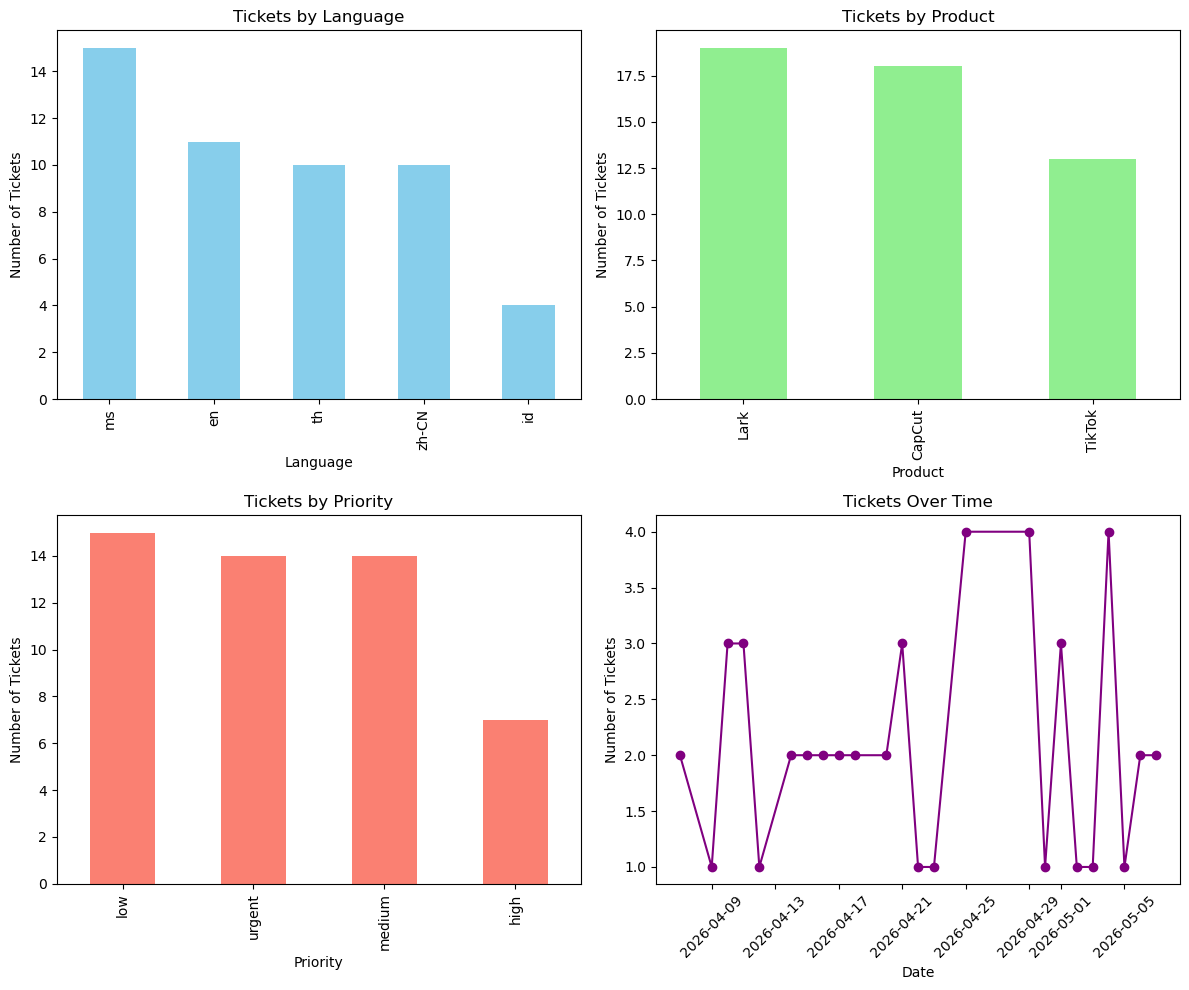


📊 Visualization saved as 'data_visualization.png'


In [8]:
# Cell 7: Create data visualizations for README
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Language distribution
lang_dist.plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Tickets by Language')
axes[0,0].set_xlabel('Language')
axes[0,0].set_ylabel('Number of Tickets')

# 2. Product distribution
prod_dist.plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Tickets by Product')
axes[0,1].set_xlabel('Product')
axes[0,1].set_ylabel('Number of Tickets')

# 3. Priority distribution
priority_dist.plot(kind='bar', ax=axes[1,0], color='salmon')
axes[1,0].set_title('Tickets by Priority')
axes[1,0].set_xlabel('Priority')
axes[1,0].set_ylabel('Number of Tickets')

# 4. Tickets over time
tickets_df['date'] = pd.to_datetime(tickets_df['timestamp']).dt.date
daily_counts = tickets_df.groupby('date').size()
daily_counts.plot(kind='line', ax=axes[1,1], marker='o', color='purple')
axes[1,1].set_title('Tickets Over Time')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Number of Tickets')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved as 'data_visualization.png'")

In [9]:
# Cell 8: Preview what Notebook 2 will load
print("\n" + "="*60)
print("🔮 PREVIEW FOR NOTEBOOK 2 (embedding_retrieval)")
print("="*60)

# Show a sample we'll use for retrieval
sample_kb_texts = kb_df['content'].tolist()
print(f"\n📚 Knowledge base texts (will be embedded in Notebook 2):")
for i, text in enumerate(sample_kb_texts[:3], 1):
    print(f"\n   [{i}] {text[:150]}...")

print(f"\n🔍 Sample queries (will be used for retrieval testing):")
sample_queries = tickets_df['user_query'].head(3).tolist()
for i, query in enumerate(sample_queries, 1):
    print(f"   [{i}] {query}")


🔮 PREVIEW FOR NOTEBOOK 2 (embedding_retrieval)

📚 Knowledge base texts (will be embedded in Notebook 2):

   [1] The TikTok algorithm prioritizes watch time (60%), completion rate (25%), and engagement (15%). For best results, post when your audience is active (7...

   [2] Shadowbans occur when content violates guidelines. To resolve: 1) Check account status in Settings > Report a Problem, 2) Remove violating content, 3)...

   [3] CapCut login issues: Clear cache (Settings > Apps > CapCut > Clear Cache), update to latest version, check internet connection, or use 'Forgot Passwor...

🔍 Sample queries (will be used for retrieval testing):
   [1] watermark issue with CapCut
   [2] watermark issue with CapCut
   [3] follower issue with TikTok


In [10]:
# Cell 9: Verify data integrity
print("\n" + "="*60)
print("✅ DATA INTEGRITY CHECK")
print("="*60)

# Check that all files were created correctly
import os

files_to_check = [
    'byte_dance_tickets.json',
    'knowledge_base.json',
    'ground_truth.json',
    'data_summary.json'
]

all_good = True
for file in files_to_check:
    if os.path.exists(file):
        size = os.path.getsize(file)
        print(f"✅ {file} ({size} bytes)")
    else:
        print(f"❌ {file} MISSING")
        all_good = False

if all_good:
    print("\n🎉 All data files ready for Notebook 2!")
    print("\n📋 Next steps:")
    print("   1. Open 02_embedding_retrieval.ipynb")
    print("   2. Load 'knowledge_base.json' instead of hardcoded kb_texts")
    print("   3. Load 'byte_dance_tickets.json' for test queries")


✅ DATA INTEGRITY CHECK
✅ byte_dance_tickets.json (14612 bytes)
✅ knowledge_base.json (2661 bytes)
✅ ground_truth.json (8389 bytes)
✅ data_summary.json (488 bytes)

🎉 All data files ready for Notebook 2!

📋 Next steps:
   1. Open 02_embedding_retrieval.ipynb
   2. Load 'knowledge_base.json' instead of hardcoded kb_texts
   3. Load 'byte_dance_tickets.json' for test queries
